In [1]:
!pip install mlflow dagshub optuna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14

In [2]:
import numpy as np
import pandas as pd
import utils_data_clean
import mlflow
import optuna
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,StackingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
import dagshub
dagshub.init(repo_owner='Iamkartikey44', repo_name='Food_Delivery_Time_Prediction', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=28ee585b-b316-46dc-bc4f-970f503f98cc&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=7988add8321ccdb6408dbab0fd177944d5dcf18b6d35eca739cc2964e845d6c1




Accessing as Iamkartikey44

Initialized MLflow to track repo "Iamkartikey44/Food_Delivery_Time_Prediction"

Repository Iamkartikey44/Food_Delivery_Time_Prediction initialized!

In [4]:
#Mlflow Experiment
mlflow.set_experiment("Exp5 -  Final Estimator")

2026/03/08 18:46:32 INFO mlflow.tracking.fluent: Experiment with name 'Exp5 -  Final Estimator' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1359cf99c1264ae29e5e9a35c8d3da80', creation_time=1772995592241, experiment_id='5', last_update_time=1772995592241, lifecycle_stage='active', name='Exp5 -  Final Estimator', tags={}, workspace='default'>

In [5]:
from sklearn import set_config
set_config(transform_output='pandas')

In [6]:
#Load the data
df = pd.read_csv("swiggy.csv")

In [7]:
# load the cleaned data
df = pd.read_csv('swiggy_cleaned.csv')

In [8]:
df['distance_type'] = pd.cut(df["distance"],bins=[0,5,10,15,25],
                                        right=False,labels=["short","medium","long","very_long"])

In [9]:
df.sample(10)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
21241,JAPRES13DEL02,23.0,4.5,26.846156,75.802300,26.866156,75.822300,2022-03-05,fog,low,...,JAP,5,3,saturday,1,5.0,9.0,morning,2.980290,short
22913,JAPRES19DEL01,32.0,4.7,26.913726,75.752820,26.923726,75.762821,2022-03-03,sandstorms,low,...,JAP,3,3,thursday,0,5.0,8.0,morning,1.489845,short
29261,HYDRES010DEL03,33.0,4.9,17.428294,78.404423,17.458294,78.434423,2022-03-13,fog,jam,...,HYD,13,3,sunday,1,10.0,19.0,evening,4.610406,short
11846,ALHRES11DEL02,37.0,4.7,NaN,NaN,NaN,NaN,2022-02-12,sunny,medium,...,ALH,12,2,saturday,1,5.0,18.0,evening,NaN,NaN
27538,VADRES01DEL02,20.0,4.5,22.307898,73.167788,22.387898,73.247788,2022-03-23,sunny,jam,...,VAD,23,3,wednesday,0,5.0,19.0,evening,12.117044,long
10888,MUMRES03DEL01,20.0,4.8,19.223840,72.841347,19.333840,72.951347,2022-03-02,cloudy,low,...,MUM,2,3,wednesday,0,10.0,23.0,night,16.819857,very_long
32105,HYDRES07DEL02,26.0,4.8,17.424114,78.347554,17.504114,78.427554,2022-03-06,stormy,medium,...,HYD,6,3,sunday,1,10.0,17.0,evening,12.293746,long
12296,INDORES01DEL02,34.0,4.9,22.695207,75.866059,22.715207,75.886059,2022-03-15,sunny,low,...,INDO,15,3,tuesday,0,5.0,10.0,morning,3.025656,short
6153,MUMRES09DEL03,35.0,4.3,18.994049,72.825203,19.024049,72.855203,2022-03-28,fog,jam,...,MUM,28,3,monday,0,5.0,21.0,night,4.590772,short
27504,RANCHIRES16DEL02,39.0,4.3,23.371292,85.327872,23.421292,85.377872,2022-04-03,fog,jam,...,RANCHI,3,4,sunday,1,10.0,19.0,evening,7.546361,medium


In [10]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [11]:
#Drop columns not required for model input
columns_to_drop = ["rider_id","restaurant_latitude",'restaurant_longitude','delivery_latitude','delivery_longitude','order_date','order_time_hour','order_day','city_name','order_day_of_week','order_month']
df.drop(columns=columns_to_drop,inplace=True)

In [12]:
# check for missing values
df.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [13]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

<Axes: >

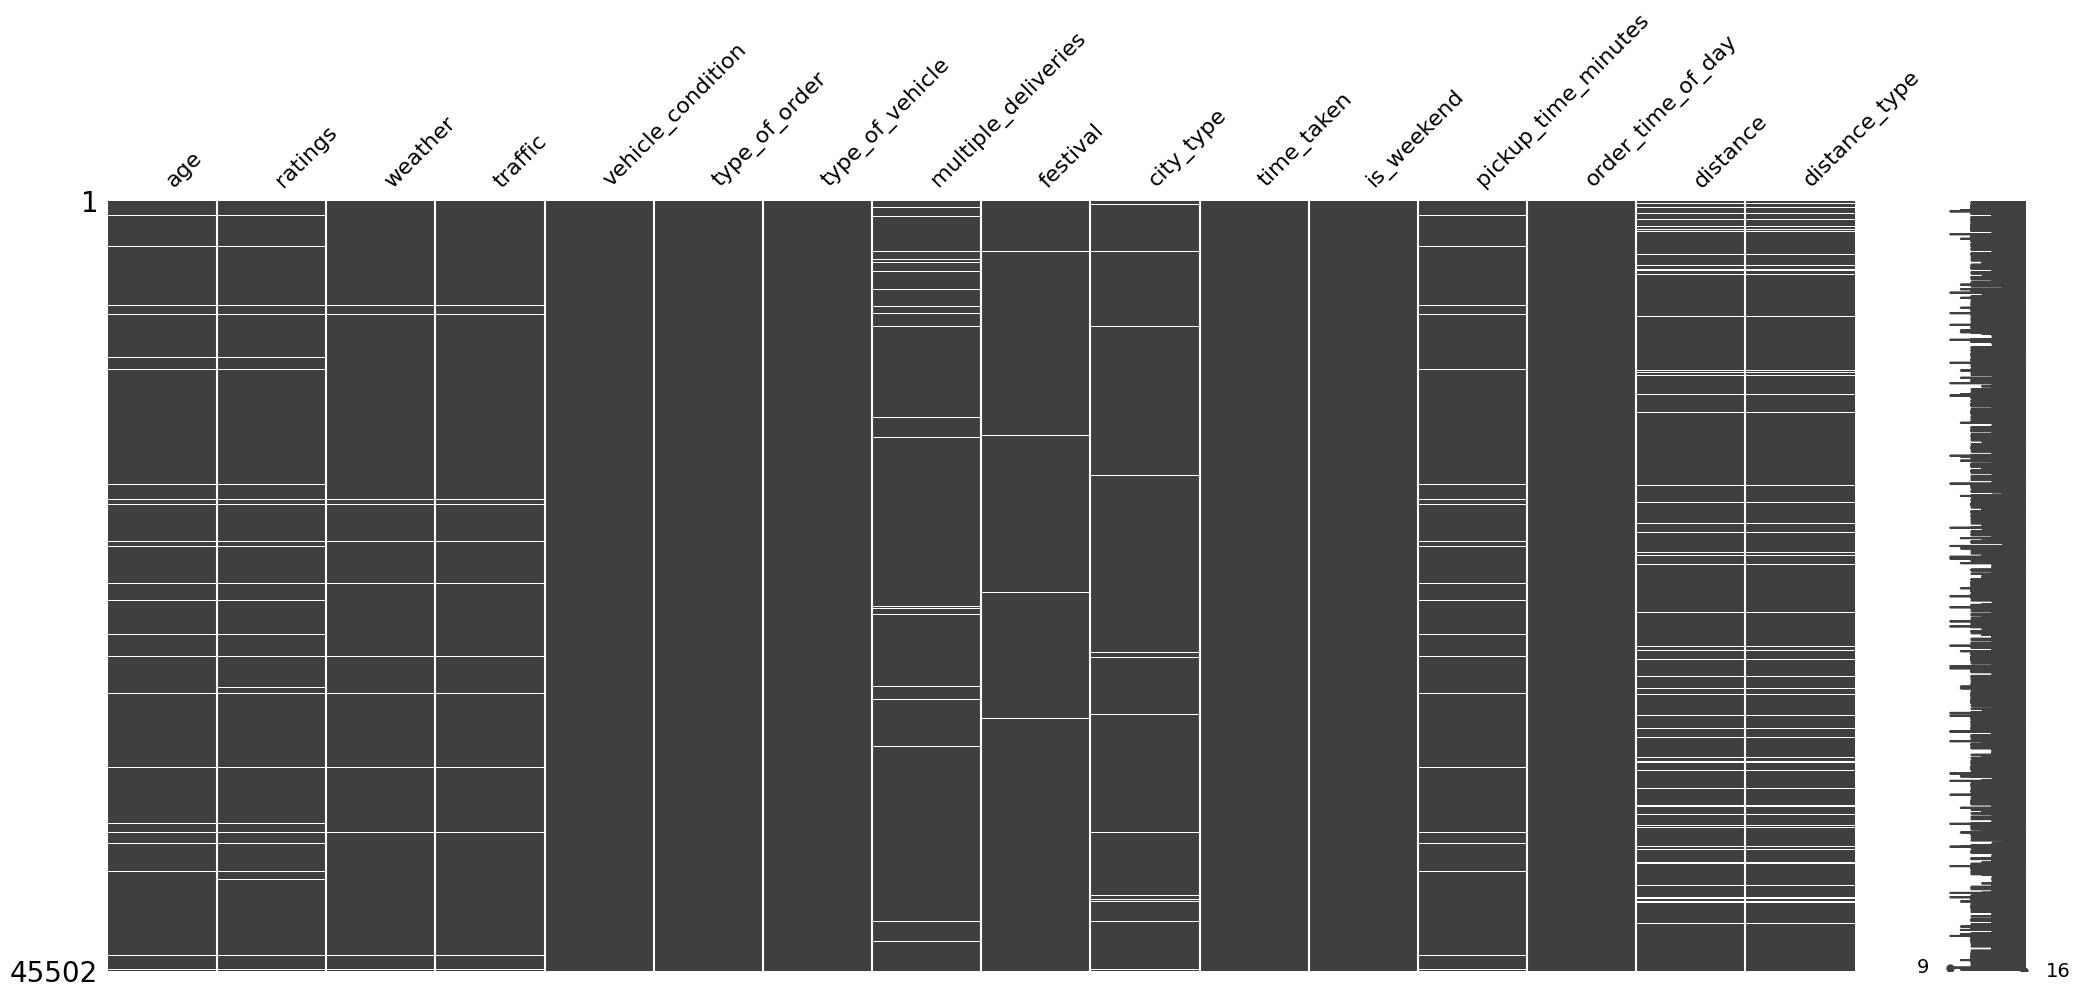

In [14]:
msno.matrix(df)

In [15]:
#Columns that have missing values
missing_cols = df.isna().any(axis=0).loc[lambda x:x].index
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance',
       'distance_type'],
      dtype='object')

In [16]:
#Drop Missing Values
temp_df = df.copy().dropna()

In [17]:
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30451, 15)
The shape of test data is (7613, 15)


In [20]:
X_train.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [21]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [22]:
# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [23]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'is_weekend',
                                  'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [24]:
# build the pipeline
processing_pipeline  = Pipeline(steps=[
    ("preprocess",preprocessor)
])

In [25]:
# do data preprocessing
X_train_trans = processing_pipeline.fit_transform(X_train)
X_test_trans = processing_pipeline.transform(X_test)

In [32]:
xgb_params = {'n_estimators': 415,
 'max_depth': 20,
 'learning_rate': 0.29263456258035475,
 'subsample': 0.8759669065136347,
 'colsample_bytree': 0.7213914971809194,
 'min_child_weight': 17,
 'gamma': 1.0059958323704052,
 'reg_lambda': 37.94112216359326,
 'reg_alpha': 0.5695261402488025}

lgbm_params ={'n_estimators': 398,
 'max_depth': 30,
 'learning_rate': 0.17723976615372525,
 'subsample': 0.6668154532640596,
 'min_child_weight': 13,
 'min_split_gain': 0.00042029710843746043,
 'reg_lambda': 75.85847527149905}

rf_params =  {'n_estimators': 500,
 'max_depth': 14,
 'max_features': None,
 'min_samples_split': 9,
 'min_samples_leaf': 6,
 'max_samples': 0.9797814656591307}


xgb_reg = XGBRegressor(**xgb_params)
lgbm_reg = LGBMRegressor(**lgbm_params)
rf_reg = RandomForestRegressor(**rf_params)
#stacking_reg = StackingRegressor(estimators=[('XGBoost',xgb_reg),('lgbm',lgbm_reg),('rf',rf_reg)],final_estimator=meta,cv=5,n_jobs=-1)

In [26]:
# build the best models

best_rf_params = {'n_estimators': 479,
 'criterion': 'squared_error',
 'max_depth': 17,
 'max_features': None,
 'min_samples_split': 9,
 'min_samples_leaf': 2,
 'max_samples': 0.6603673526197067}

best_lgbm_params = {'n_estimators': 154,
 'max_depth': 27,
 'learning_rate': 0.22234435854395157,
 'subsample': 0.7592213724048168,
 'min_child_weight': 20,
 'min_split_gain': 0.004604680609280751,
 'reg_lambda': 97.81002379097947}

best_rf = RandomForestRegressor(**best_rf_params)
best_lgbm = LGBMRegressor(**best_lgbm_params)

lr = LinearRegression()

In [27]:
#Transform target column
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [33]:
# build the stacking regressor
#stacking_reg = StackingRegressor(estimators=[('rf',best_rf),('lgbm',best_lgbm)],final_estimator=lr,cv=5,n_jobs=-1)
stacking_reg = StackingRegressor(estimators=[('XGBoost',xgb_reg),('lgbm',lgbm_reg),('rf',rf_reg)],final_estimator=lr,cv=5,n_jobs=-1)
model =TransformedTargetRegressor(regressor=stacking_reg,transformer=pt)
# train the model
model.fit(X_train_trans,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but PowerTransformer was fitted without feature names
  warnings.warn(


TransformedTargetRegressor(regressor=StackingRegressor(cv=5,
                                                       estimators=[('XGBoost',
                                                                    XGBRegressor(base_score=None,
                                                                                 booster=None,
                                                                                 callbacks=None,
                                                                                 colsample_bylevel=None,
                                                                                 colsample_bynode=None,
                                                                                 colsample_bytree=0.7213914971809194,
                                                                                 device=None,
                                                                                 early_stopping_rounds=None,
                                                                                 enable_categorical=False,
                                                                                 eval_metric=None,
                                                                                 feature_types=None,
                                                                                 feature_weights=None,
                                                                                 gamma=1....
                                                                                  min_child_weight=13,
                                                                                  min_split_gain=0.00042029710843746043,
                                                                                  n_estimators=398,
                                                                                  reg_lambda=75.85847527149905,
                                                                                  subsample=0.6668154532640596)),
                                                                   ('rf',
                                                                    RandomForestRegressor(max_depth=14,
                                                                                          max_features=None,
                                                                                          max_samples=0.9797814656591307,
                                                                                          min_samples_leaf=6,
                                                                                          min_samples_split=9,
                                                                                          n_estimators=500))],
                                                       final_estimator=LinearRegression(),
                                                       n_jobs=-1),
                           transformer=PowerTransformer())

In [34]:
# get the train and test predictions
y_train_pred = model.predict(X_train_trans)
y_test_pred = model.predict(X_test_trans)

# calculate the train and test mae
train_mae = mean_absolute_error(y_train,y_train_pred)
test_mae = mean_absolute_error(y_test,y_test_pred)

# calculate the r2 scores
train_r2 = r2_score(y_train,y_train_pred)
test_r2 = r2_score(y_test,y_test_pred)

# calculate cross val scores
cv_scores = cross_val_score(model,X_train_trans,y_train,cv=3,scoring="neg_mean_absolute_error",n_jobs=-1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [35]:
-cv_scores

array([2.99806122, 3.06515733, 3.04699866])

In [30]:
# get the train and test predictions
y_train_pred = model.predict(X_train_trans)
y_test_pred = model.predict(X_test_trans)

# calculate the train and test mae
train_mae = mean_absolute_error(y_train,y_train_pred)
test_mae = mean_absolute_error(y_test,y_test_pred)

# calculate the r2 scores
train_r2 = r2_score(y_train,y_train_pred)
test_r2 = r2_score(y_test,y_test_pred)

# calculate cross val scores
cv_scores = cross_val_score(model,X_train_trans,y_train,cv=3,scoring="neg_mean_absolute_error",n_jobs=-1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [31]:
-cv_scores

array([3.01725073, 3.07982584, 3.0600798 ])

In [36]:
# log with mlflow

with mlflow.start_run():
    # set tags
    mlflow.set_tag("model","stacking regressor")

    # log parameters
    mlflow.log_params(stacking_reg.get_params())

    # log metrics
    mlflow.log_metric("train_mae",train_mae)
    mlflow.log_metric("test_mae",test_mae)
    mlflow.log_metric("train_r2",train_r2)
    mlflow.log_metric("test_r2",test_r2)
    mlflow.log_metric("cv_score",-(cv_scores.mean()))

    # log the stacking regressor
    mlflow.sklearn.log_model(stacking_reg,"model")

2026/03/08 19:18:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/08 19:18:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run indecisive-cod-33 at: https://dagshub.com/Iamkartikey44/Food_Delivery_Time_Prediction.mlflow/#/experiments/5/runs/17e927ba322146399531f981ac76bd4e
🧪 View experiment at: https://dagshub.com/Iamkartikey44/Food_Delivery_Time_Prediction.mlflow/#/experiments/5
